## ***Lab 1: ARMA Modelling of Cryptocurrencies***

In [10]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import acf, pacf, q_stat
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.optimize import minimize

***Set default layout.***

In [11]:
 default_layout = dict(
    xaxis=dict(titlefont=dict(size=25), tickfont=dict(size=20), showgrid=False),
    yaxis=dict(titlefont=dict(size=25), tickfont=dict(size=20), showgrid=False, zeroline=False),
    font=dict(family="Serif", size=20, color="black"),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    legend=dict(font=dict(size=18), bgcolor='rgba(255,255,255,0.5)', bordercolor='black', borderwidth=1),
    margin=dict(t=80, l=60, r=60, b=60)
)

# 1) Data Exploration

In [12]:
df = pd.read_excel('ethereum (1).xlsx', sheet_name='Data')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

The Price Index Return is calculated as: $$
\text{Log Return}_{t} = \ln\left(\frac{\text{Price}_{t}}{\text{Price}_{t-1}}\right) = \ln(1 + \text{pct change}_t)
$$

The Hash Rate Variation is calculated as:
$$
\text{Hash Rate Pct Change}_{t} = \frac{\text{Hash Rate}_{t} - \text{Hash Rate}_{t-1}}{\text{Hash Rate}_{t-1}} = e^{\text{Log Growth Rate}_t} - 1
$$

In [13]:
# Subplots with shared x-axis
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=("Price Index", "Price Index Return")
)

# Top panel: Price Index
fig.add_trace(
    go.Scatter(
        x=df.index, y=df["Price Index"],
        mode='lines', line=dict(color='blue', width=2),
        name='Price Index'
    ),
    row=1, col=1
)

# Bottom panel: Price Index Return
fig.add_trace(
    go.Scatter(
        x=df.index, y=df["Price Index Return"],
        mode='lines', line=dict(color='orange', width=2),
        name='Price Index Return'
    ),
    row=2, col=1
)

# Apply defaults
fig.update_layout(**default_layout, showlegend=False)

# Make subplot titles (annotations) match your typography
fig.update_annotations(font=dict(size=25, family='Serif', color='black'))

# Ensure axis fonts are consistent on both rows
fig.update_yaxes(title_text="Price Index",
                 titlefont=dict(size=25), tickfont=dict(size=20),
                 row=1, col=1)
fig.update_yaxes(title_text="Price Index Return",
                 titlefont=dict(size=25), tickfont=dict(size=20),
                 row=2, col=1)

# Only bottom x-axis shows label, but set its fonts explicitly
fig.update_xaxes(title_text="Date",
                 titlefont=dict(size=25), tickfont=dict(size=20),
                 row=2, col=1)

# Date formatting like '%Y-%m'
fig.update_xaxes(tickformat="%Y-%m", row=1, col=1)
fig.update_xaxes(tickformat="%Y-%m", row=2, col=1)

fig.show()

In [14]:
# Subplots with shared x-axis
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=("Hash Rate", "Hash Rate Variation")
)

# Top panel: Hash Rate
fig.add_trace(
    go.Scatter(
        x=df.index, y=df["Hash Rate"],
        mode='lines', line=dict(color='blue', width=2),
        name='Hash Rate'
    ),
    row=1, col=1
)

# Bottom panel: Hash Rate Variation
fig.add_trace(
    go.Scatter(
        x=df.index, y=df["Hash Rate Variation"],
        mode='lines', line=dict(color='orange', width=2),
        name='Hash Rate Variation'
    ),
    row=2, col=1
)

# Apply defaults first
fig.update_layout(**default_layout, showlegend=False)

# Make subplot titles/annotations match your typography
fig.update_annotations(font=dict(size=25, family='Serif', color='black'))

# Axis titles & fonts
fig.update_yaxes(title_text="Hash Rate",
                 titlefont=dict(size=25), tickfont=dict(size=20),
                 row=1, col=1)
fig.update_yaxes(title_text="Hash Rate Variation",
                 titlefont=dict(size=25), tickfont=dict(size=20),
                 row=2, col=1)

# Bottom x-axis label; date formatting on both panels
fig.update_xaxes(title_text="Date",
                 titlefont=dict(size=25), tickfont=dict(size=20),
                 tickformat="%Y-%m", row=2, col=1)
fig.update_xaxes(tickformat="%Y-%m", row=1, col=1)

fig.show()

# 2) Regression Analysis

Constant Expected Return Model (CER):

In [15]:
df_CER = df.copy()
X = np.ones((len(df_CER['Price Index Return']), 1))
y = df_CER["Price Index Return"]
model = sm.OLS(y, X)
results_sm = model.fit()
print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:     Price Index Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 01 Jul 2026   Prob (F-statistic):                nan
Time:                        20:11:21   Log-Likelihood:                 1680.8
No. Observations:                1092   AIC:                            -3360.
Df Residuals:                    1091   BIC:                            -3355.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0029      0.002      1.871      0.0

In [16]:
constant_CER = df_CER["Price Index Return"].mean()
variance_epsilon_CER = df_CER["Price Index Return"].var()

In [17]:
constant_CER

np.float64(0.002940374340743597)

Predictive regression based on the lagged hash rate variation:

In [18]:
df_regression=df.copy()
df_regression["Lagged Hash Rate Variation"]=df_regression["Hash Rate Variation"].shift(1)
df_regression.dropna(inplace=True)

In [19]:
df_regression

,Price Index,Price Index Return,Hash Rate,Hash Rate Variation,Lagged Hash Rate Variation
Date,,,,,
2019-02-01,106.76,0.004318,143116.0140,-0.046076,0.032532
2019-02-02,110.47,0.034161,143036.2313,-0.000557,-0.046076
2019-02-03,107.38,-0.028370,139150.9121,-0.027163,-0.000557
2019-02-04,107.73,0.003254,141058.0782,0.013706,-0.027163
2019-02-05,107.20,-0.004932,141593.6815,0.003797,0.013706
...,...,...,...,...,...
2022-01-27,2424.67,-0.014994,993377.3777,-0.001863,0.028718
2022-01-28,2545.99,0.048824,981166.5036,-0.012292,-0.001863
2022-01-29,2600.33,0.021119,989415.7732,0.008408,-0.012292


In [20]:
X = df_regression["Lagged Hash Rate Variation"]
y = df_regression["Price Index Return"]

In [21]:
X_with_constant = sm.add_constant(X)
model = sm.OLS(y, X_with_constant)
results_sm = model.fit()
print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:     Price Index Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.03482
Date:                Wed, 01 Jul 2026   Prob (F-statistic):              0.852
Time:                        20:11:21   Log-Likelihood:                 1678.8
No. Observations:                1091   AIC:                            -3354.
Df Residuals:                    1089   BIC:                            -3344.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

# 3) Stationarity

# Create functions to compute and plot the SACF and the SPACF.

In [22]:
def SACF_SPACF(series, lag_max = 24, alpha_level = 0.05, model_df = 0):
    """
    Compute the sample autocorrelation function (SACF), sample partial autocorrelation function (SPACF),
    and Ljung-Box Q-statistics for the SACF.

    This function calculates the ACF and PACF values along with their corresponding confidence intervals
    for lags 1 through `lag_max` using the provided significance level (`alpha_level`). In addition, it
    computes the Ljung-Box Q-statistic and associated p-values (excluding lag 0) for the SACF.

    Set `model_df` to the number of dof lost (= number of conditional mean coefficents estimated,
    i.e. all coeffs excluding the intercept).

    """

    # Calculate ACF and PACF with confidence intervals
    acf_vals, acf_confint = acf(series, nlags=lag_max, alpha=alpha_level)
    pacf_vals, pacf_confint = pacf(series, nlags=lag_max, alpha=alpha_level, method='ols')

    # Calculate Ljung-Box statistics and p-values
    lb_results = sm.stats.acorr_ljungbox(
        series,
        lags=range(1, lag_max + 1),
        model_df=model_df,
        return_df=True
    )

    # Build the results DataFrame
    df_acf_pacf = pd.DataFrame({
        "Lag": np.arange(1, lag_max + 1),
        "ACF": acf_vals[1:],
        "ACF_lower": acf_confint[1:, 0],
        "ACF_upper": acf_confint[1:, 1],
        "PACF": pacf_vals[1:],
        "PACF_lower": pacf_confint[1:, 0],
        "PACF_upper": pacf_confint[1:, 1],
        "Q-stat": lb_results["lb_stat"].values,
        "Q-stat Prob": lb_results["lb_pvalue"].values.round(6)
    })

    # Set the index to 'Lag' and extract the main columns
    df_acf_pacf.set_index("Lag", inplace=True)
    df_acf_pacf_small = df_acf_pacf[["ACF", "PACF", "Q-stat", "Q-stat Prob"]].copy()

    return df_acf_pacf_small

In [23]:
def SACF_SPACF_plotly(series, lag_max=24, ylim=(-0.15, 0.15)):
    # Compute ACF and PACF with confidence intervals
    acf_vals, acf_conf = acf(series, nlags=lag_max, alpha=0.05)
    pacf_vals, pacf_conf = pacf(series, nlags=lag_max, alpha=0.05, method='ols')

    lags = list(range(1, lag_max+1))

    fig = make_subplots(rows=1, cols=2, subplot_titles=("SACF", "SPACF"))

    # ACF: bars + CIs
    fig.add_trace(go.Bar(
        x=lags, y=acf_vals[1:], marker_color='blue', opacity=0.7,
        showlegend=False
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=lags, y=acf_conf[1:,0], mode='lines',
        line=dict(color='grey', width=2),
        showlegend=False
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=lags, y=acf_conf[1:,1], mode='lines',
        line=dict(color='grey', width=2),
        fill='tonexty', fillcolor='rgba(128,128,128,0.15)',
        showlegend=False
    ), row=1, col=1)

    # PACF: bars + CIs
    fig.add_trace(go.Bar(
        x=lags, y=pacf_vals[1:], marker_color='blue', opacity=0.7,
        showlegend=False
    ), row=1, col=2)

    fig.add_trace(go.Scatter(
        x=lags, y=pacf_conf[1:,0], mode='lines',
        line=dict(color='grey', width=2),
        showlegend=False
    ), row=1, col=2)

    fig.add_trace(go.Scatter(
        x=lags, y=pacf_conf[1:,1], mode='lines',
        line=dict(color='grey', width=2),
        fill='tonexty', fillcolor='rgba(128,128,128,0.15)',
        showlegend=False
    ), row=1, col=2)

    # Layout
    fig.update_yaxes(range=ylim, row=1, col=1)
    fig.update_yaxes(range=ylim, row=1, col=2)

    fig.update_layout(
        title=dict(text='SACF and SPACF', x=0.5, font=dict(size=28, family='Serif', color='black')),
        font=dict(family="Serif", size=18, color="black"),
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='rgba(0,0,0,0)',
        margin=dict(t=80, l=60, r=60, b=60),
        showlegend=False
    )

    fig.show()

# Prices

In [24]:
prices = df["Price Index"].values

In [25]:
prices_acf_pacf = SACF_SPACF(prices,lag_max=20)
prices_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,0.996949,0.998072,1088.330811,0.0
2,0.994449,0.110297,2172.203396,0.0
3,0.991780,-0.027114,3251.256710,0.0
4,0.989186,0.000876,4325.659316,0.0
5,0.986371,-0.069586,5394.937409,0.0
6,0.983932,0.077620,6459.915655,0.0
7,0.980993,-0.094158,7519.516587,0.0
8,0.978252,0.016420,8574.175441,0.0
9,0.975458,0.019020,9623.787688,0.0


In [26]:
SACF_SPACF_plotly(prices, lag_max=20, ylim=[-0.15,1.35])

# Returns

In [27]:
start = float(df["Price Index Return"].min())
end_raw = float(df["Price Index Return"].max())
size = (end_raw - start) / 30.0
end = start + size * 30

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=df["Price Index Return"],
    xbins=dict(start=start, end=end, size=size),
    marker=dict(color='blue', line=dict(color='black', width=1)),
    name='Price Index Returns',
    opacity=0.6
))

fig.update_layout(
    **default_layout,  # apply defaults first
    title=dict(text='Histogram (estimate)', x=0.5, font=dict(size=30, family='Serif', color='black')),
    xaxis_title='Price Index Returns',
    yaxis_title='Frequency',
    bargap=0.05,
    showlegend=False
)

fig.show()

In [28]:
df_monday = df[df.index.weekday == 0]   # 0 is Monday here
df_tuesday = df[df.index.weekday == 1]  # 1 is Tuesday here
df_wednesday = df[df.index.weekday == 2]  # etc.
df_thursday = df[df.index.weekday == 3]
df_friday = df[df.index.weekday == 4]
df_saturday = df[df.index.weekday == 5]
df_sunday = df[df.index.weekday == 6]

In [29]:
df_dayofweek = df_thursday.copy()

In [30]:
start = float(df_dayofweek["Price Index Return"].min())
end_raw = float(df_dayofweek["Price Index Return"].max())
size = (end_raw - start) / 20.0
end = start + size * 20

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=df_dayofweek["Price Index Return"],
    xbins=dict(start=start, end=end, size=size),
    marker=dict(color='blue', line=dict(color='black', width=1)),
    name='Price Index Returns',
    opacity=0.6
))

fig.update_layout(
    **default_layout,  # apply defaults first
    title=dict(text='Histogram (estimate)', x=0.5, font=dict(size=30, family='Serif', color='black')),
    xaxis_title='Price Index Returns',
    yaxis_title='Frequency',
    bargap=0.05,
    showlegend=False
)

fig.show()

# 4) The Sample Autocorrelation Function (SACF) and the Sample Partial Autocorrelation Function (SPACF) of Returns

In [31]:
returns = df["Price Index Return"].values

In [32]:
returns_acf_pacf = SACF_SPACF(returns)
returns_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,-0.115459,-0.115491,14.597207,0.000133
2,0.075615,0.063141,20.863712,0.000029
3,-0.051995,-0.037172,23.829449,0.000027
4,0.093304,0.080556,33.388484,0.000001
5,-0.046615,-0.023298,35.776612,0.000001
6,0.030411,0.010925,36.793950,0.000002
7,-0.039738,-0.025323,38.532620,0.000002
8,0.010166,-0.008695,38.646507,0.000006
9,-0.041007,-0.031028,40.501410,0.000006


# UN-PACKING! Sample Autocorrelation Function

Generally speaking:
$$
\rho(k) = \frac{\sum_{t=k+1}^{T} (x_t - \overline{x}) (x_{t-k} - \overline{x})}
               {\sum_{t=1}^{T}   (x_t - \overline{x})^2}
$$



$$
\rho(k)' = \frac{\frac{1}{T-k}\sum_{t=k+1}^{T} \left(x_t - \overline{x_{t}}\right)\left(x_{t-k} - \overline{x_{t-k}}\right)}
{\sqrt{\frac{1}{T}\sum_{t=1}^{T} \left(x_t - \overline{x_{t}}\right)^2} \,
 \sqrt{\frac{1}{T-k}\sum_{t=k+1}^{T} \left(x_t - \overline{x_{t-k}}\right)^2}}
$$


$\rho(k)'$ is a formula that precisely accounts for the fact that the two standard deviations at the denominator are estimated on the basis of a different number of observations

Suppose we want to find $\rho(1)$:

$$
\rho(1) = \frac{\sum_{t=2}^{T} (x_t - \overline{x}) (x_{t-1} - \overline{x})}
               {\sum_{t=1}^{T}   (x_t - \overline{x})^2}
$$


$$
\rho(1)' = \frac{\frac{1}{T-1}\sum_{t=2}^{T} \left(x_t - \overline{x_{t}}\right)\left(x_{t-1} - \overline{x_{t-1}}\right)}
{\sqrt{\frac{1}{T}\sum_{t=1}^{T} \left(x_t - \overline{x_{t}}\right)^2} \,
 \sqrt{\frac{1}{T-1}\sum_{t=2}^{T} \left(x_t - \overline{x_{t-1}}\right)^2}}
$$

*Set up of comparison between the ACF formula given in the lectures and the precise formula that one may want to compare and use instead*

In [33]:
SACF_df = df[['Price Index Return']].copy()
SACF_df.rename(columns={'Price Index Return': 'return_t'}, inplace=True)
SACF_df['return_t_minus_1'] = SACF_df['return_t'].shift(+1)

In [34]:
mean_r_t = np.asarray(SACF_df['return_t']).mean()

In [35]:
SACF_df['return_t'] = SACF_df['return_t'] - mean_r_t
SACF_df['return_t_minus_1'] = SACF_df['return_t_minus_1'] - mean_r_t

*Denominator.*

In [36]:
SACF_df['return_t_demeaned_squared'] = (SACF_df['return_t'])**2
SACF_denominator = SACF_df['return_t_demeaned_squared'].sum()

*Numerator.*

In [37]:
SACF_df = SACF_df.copy().dropna()
SACF_df['return_t*return_t_minus_1'] = SACF_df['return_t'].copy()*SACF_df['return_t_minus_1'].copy()

In [38]:
SACF_numerator = SACF_df['return_t*return_t_minus_1'].sum()

*Calculate the sample autocorrelation function at lag 1.*

In [39]:
rho_1 = SACF_numerator/SACF_denominator
rho_1

np.float64(-0.1154588629705565)

# UN-PACKING! Sample Partial Autocorrelation Function

$$
\begin{aligned}
x_t &= \beta_0 + \beta_1 x_{t-1} + \beta_2 x_{t-2} + \cdots + \beta_k x_{t-k} + \varepsilon_t,\quad t=k+1,\dots,T, \\
X &= \begin{pmatrix}
1 & 1 & \cdots & 1 \\
x_{k} & x_{k-1} & \cdots & x_{1} \\
x_{k+1} & x_{k} & \cdots & x_{2} \\
\vdots & \vdots & \ddots & \vdots \\
x_{T-1} & x_{T-2} & \cdots & x_{T-k}
\end{pmatrix},\quad
y = \begin{pmatrix}
x_{k+1} \\
x_{k+2} \\
\vdots \\
x_{T}
\end{pmatrix}, \\
\end{aligned}
$$


$$
\begin{aligned}
\hat{\beta} &= (X^\top X)^{-1} X^\top y, \\
\end{aligned}
$$

$$
\begin{aligned}
\hat{\phi}(k) &= \hat{\beta}_k.
\end{aligned}
$$

In [40]:
SPACF_df = df[['Price Index Return']].copy()
SPACF_df.rename(columns={'Price Index Return': 'return_t'}, inplace=True)
SPACF_df['return_t_minus_1'] = SPACF_df['return_t'].shift(+1)
SPACF_df['return_t_minus_2'] = SPACF_df['return_t'].shift(+2)

In [41]:
SPACF_df.dropna(inplace = True)

In [42]:
y = SPACF_df["return_t"]
X = SPACF_df["return_t_minus_1"]

In [43]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

In [44]:
phi_1 = float(model.params["return_t_minus_1"])
phi_1

-0.11549996980609233

In [45]:
y = SPACF_df["return_t"]
X = SPACF_df[["return_t_minus_1","return_t_minus_2"]]

In [46]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

In [47]:
phi_2 = float(model.params["return_t_minus_2"])
phi_2

0.06314142566669521

# Plotting the SACF and SPACF for Returns

Recall that:

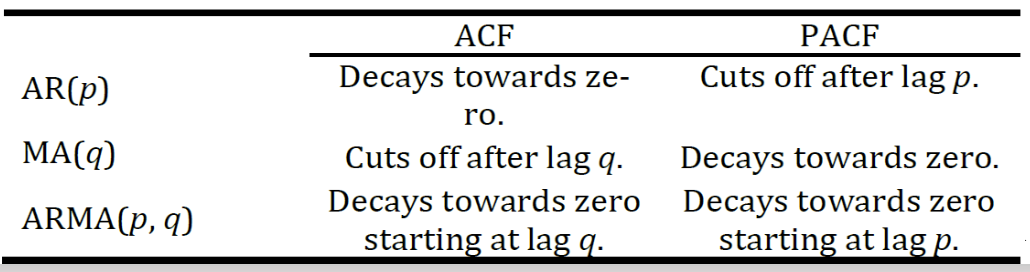

In [48]:
SACF_SPACF_plotly(returns, ylim = [-0.30, 0.30])

# 5) Moving Average Model

An MA(4) model is defined as:

$$
Y_t = \mu  + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_3 \varepsilon_{t-3} + \theta_4 \varepsilon_{t-4} + \varepsilon_t,
$$

where:

- $Y_t$ is the observed time series.
- $\mu$ is the mean of the series.
- $\varepsilon_t$ is white noise with zero mean and constant variance.
- $\mu, \theta_1, \theta_2, \theta_3, \theta_4$ are the parameters of the model.

In [49]:
model = sm.tsa.statespace.SARIMAX(
    returns,
    order=(0, 0, 4),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1092
Model:               SARIMAX(0, 0, 4)   Log Likelihood                1683.999
Date:                Wed, 01 Jul 2026   AIC                          -3355.998
Time:                        20:11:23   BIC                          -3326.051
Sample:                             0   HQIC                         -3344.662
                               - 1092                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0030      0.002      1.708      0.088      -0.000       0.006
ma.L1         -0.0985      0.021     -4.594      0.000      -0.141      -0.057
ma.L2          0.0632      0.029      2.200      0.0

In [50]:
AIC = -2*1683.999+2*6
AIC

-3355.998

In [51]:
BIC = float(-2*1683.999+(np.log(1092))*6)
BIC

-3326.023403062171

In [52]:
HQIC = float(-2*1683.999+np.log((np.log(1092)))*6*2)
HQIC

-3344.6543384249358

In [53]:
residuals = results.resid
residuals_acf_pacf = SACF_SPACF(residuals) #model_df=4
residuals_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,-0.003706,-0.003707,0.015043,0.902384
2,0.001472,0.001459,0.017418,0.991329
3,-0.003641,-0.003632,0.031959,0.998495
4,0.003103,0.003076,0.042529,0.999777
5,-0.040747,-0.040773,1.867238,0.867193
6,0.013701,0.013444,2.073737,0.912794
7,-0.025544,-0.025406,2.792195,0.903538
8,-0.006046,-0.006607,2.832478,0.944426
9,-0.025539,-0.025235,3.551963,0.938357


In [54]:
SACF_SPACF_plotly (residuals, lag_max=24, ylim = [-0.15, 0.17])

Remove the MA(3) component and estimate:

$$
Y_t = \mu  + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_4 \varepsilon_{t-4} + \varepsilon_t,
$$

where:

- $Y_t$ is the observed time series.
- $\mu$ is the mean of the series.
- $\varepsilon_t$ is white noise with zero mean and constant variance.
- $\mu, \theta_1, \theta_2, \theta_4$ are the parameters of the model.

In [55]:
model = sm.tsa.statespace.SARIMAX(
    returns,
    order=(0, 0, 4),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)
constrained_results = model.fit_constrained({'ma.L3': 0})

In [56]:
print(constrained_results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1092
Model:               SARIMAX(0, 0, 4)   Log Likelihood                1683.351
Date:                Wed, 01 Jul 2026   AIC                          -3356.702
Time:                        20:11:23   BIC                          -3331.746
Sample:                             0   HQIC                         -3347.256
                               - 1092                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0030      0.002      1.674      0.094      -0.001       0.006
ma.L1            -0.0970      0.021     -4.558      0.000      -0.139      -0.055
ma.L2             0.0620      0.028     

Add the MA(10) component and estimate:

$$
Y_t = \mu  + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_4 \varepsilon_{t-4} + \theta_{10} \varepsilon_{t-10} + \varepsilon_t,
$$

where:

- $Y_t$ is the observed time series.
- $\mu$ is the mean of the series.
- $\varepsilon_t$ is white noise with zero mean and constant variance.
- $\mu, \theta_1, \theta_2, \theta_4, \theta_{10}$ are the parameters of the model.

In [57]:
model = sm.tsa.statespace.SARIMAX(
    returns,
    order=(0, 0, 10),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)
constrained_results = model.fit_constrained({'ma.L3': 0, 'ma.L5': 0, 'ma.L6': 0, 'ma.L6': 0, 'ma.L7': 0,
                                             'ma.L8': 0, 'ma.L9': 0,})

In [58]:
print(constrained_results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1092
Model:              SARIMAX(0, 0, 10)   Log Likelihood                1680.079
Date:                Wed, 01 Jul 2026   AIC                          -3348.158
Time:                        20:11:25   BIC                          -3318.244
Sample:                             0   HQIC                         -3336.832
                               - 1092                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0029      0.002      1.451      0.147      -0.001       0.007
ma.L1            -0.0840      0.020     -4.187      0.000      -0.123      -0.045
ma.L2             0.0635      0.029     

# UN-PACKING! Moving Average Model

Recall, an MA(4) model is defined as:

$$
Y_t = \mu  + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_3 \varepsilon_{t-3} + \theta_4 \varepsilon_{t-4} + \varepsilon_t,
$$

where:

- $Y_t$ is the observed time series.
- $\mu$ is the mean of the series.
- $\varepsilon_t$ is white noise with zero mean and constant variance.
- $\mu, \theta_1, \theta_2, \theta_3, \theta_4$ are the parameters of the model.

**If it helps for your understanding, this is how the MLE works:**

Since we do not observe the variables on the right hand side! We have to use a different approach: Maximum Likelihood Estimation (MLE) 👑

Likelihood Function ($\mathscr{L}$): Given a sample $\underline{Y}$ and assuming to have observed $\underline{y}$, the PMF or PDF of $\underline{Y}$ ($f_{\theta}^{\underline{Y}}(\underline{y})$), seen as a function of $\theta$ for a fixed $\underline{y}$ (sample realisation) is termed likelihood function and it is indicated as $\mathscr{L}(\theta;\underline{y})=\mathscr{L}(\theta)=f_{\theta}^{\underline{Y}}(\underline{y})$ for $\theta \in \Theta$, $\underline{y} \in \underline{Y}$ fixed.

We estimate $\Theta$ in 2 ways:


1.   Method of Moments (MOM) which we will encounter later.
2.   Maximum Likelihood Estimation (MLE): can compute it analytically (differentiate the log-likelihood and solve for the estimator) or numerically (cannot differentiate use algorithms, e.g. Newton-Raphson Algorithm) **= OUR CASE**.

MLE computed numerically, 2 ways: ($\epsilon_{0}$=$\epsilon_{t-1}$=0 , $\epsilon_{-1}$=$\epsilon_{t-2}$=0, $\epsilon_{-2}$=$\epsilon_{t-3}$=0, $\epsilon_{-3}$=$\epsilon_{t-4}$=0)

1.   conditional on the initial value of $\epsilon_0$, $\epsilon_{-1}$, $\epsilon_{-2}$, $\epsilon_{-3}$: fixing them to any real value, e.g. 0.
2.   exact: gridsearching $\epsilon_0$ = $\epsilon_{-1}$ = $\epsilon_{-2}$ = $\epsilon_{-3}$ and reoptimizing.

In [59]:
mle_ma = pd.DataFrame()
mle_ma['Y'] = df['Price Index Return']
mle_ma.reset_index(drop=True, inplace=True)

In [60]:
mle_ma

,Y
0,-0.018900
1,0.004318
2,0.034161
3,-0.028370
4,0.003254
...,...
1087,-0.014994
1088,0.048824
1089,0.021119
1090,0.000873


In [61]:
new_index = range(len(mle_ma) + 4) #range is exclusive of the upper bound but index count starts from 0!
mle_ma = mle_ma.reindex(new_index) #the new index is longer than the current one, four additional rows are added at the end (NaN for all their values).
mle_ma['Y']= mle_ma['Y'].shift(4)  #this automatically shifts the four NaNs at the bottom to go on top, which is what we need

In [62]:
mle_ma["epsilon"] = np.nan         #create a new column and fill it with NaNs
mle_ma.loc[0, 'epsilon'] = 0.0
mle_ma.loc[1, 'epsilon'] = 0.0
mle_ma.loc[2, 'epsilon'] = 0.0
mle_ma.loc[3, 'epsilon'] = 0.0

Initial guesses for the parameters:

In [63]:
mu = mle_ma['Y'].mean(skipna=True)
theta_1 = 0.0
theta_2 = 0.0
theta_3 = 0.0
theta_4 = 0.0
var_epsilon = np.nan

In [64]:
initial_guesses = {
    "mu": mu,
    "theta_1": theta_1,
    "theta_2": theta_2,
    "theta_3": theta_3,
    "theta_4": theta_4,
    "var_e": var_epsilon
}

In [65]:
for i in range(4, len(mle_ma)):

    epsilon_t_minus_1 = mle_ma.loc[i-1, 'epsilon']
    epsilon_t_minus_2 = mle_ma.loc[i-2, 'epsilon']
    epsilon_t_minus_3 = mle_ma.loc[i-3, 'epsilon']
    epsilon_t_minus_4 = mle_ma.loc[i-4, 'epsilon']

    Y_t = mle_ma.loc[i, 'Y']

    epsilon_t = Y_t - initial_guesses["mu"] - (initial_guesses["theta_1"] * epsilon_t_minus_1)
    - (initial_guesses["theta_2"] * epsilon_t_minus_2) - (initial_guesses["theta_3"] * epsilon_t_minus_3)
    - (initial_guesses["theta_4"] * epsilon_t_minus_4)

    mle_ma.loc[i, 'epsilon'] = epsilon_t

In [66]:
mle_ma

,Y,epsilon
0,NaN,0.000000
1,NaN,0.000000
2,NaN,0.000000
3,NaN,0.000000
4,-0.018900,-0.021840
...,...,...
1091,-0.014994,-0.017935
1092,0.048824,0.045884
1093,0.021119,0.018178
1094,0.000873,-0.002068


In [67]:
-0.018900 - initial_guesses["mu"]

np.float64(-0.021840374340743596)

In [68]:
var_epsilon = mle_ma['epsilon'].var(ddof=1)
initial_guesses["var_e"] = var_epsilon

$\textbf{Log-likelihood function for a normal (Gaussian) distribution}$.
The probability density function (PDF) for a normal distribution is:
$
f(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \cdot e^{-\frac{(x - \mu)^2}{2 \sigma^2}}
$

Taking the natural logarithm of the PDF gives:
$
\ln(f(x)) = -\frac{1}{2} \ln(2 \pi \sigma^2) - \frac{(x - \mu)^2}{2 \sigma^2}
$

In [69]:
mle_ma = pd.DataFrame(mle_ma['Y'].copy(), columns=['Y'])

In [70]:
mle_ma

,Y
0,NaN
1,NaN
2,NaN
3,NaN
4,-0.018900
...,...
1091,-0.014994
1092,0.048824
1093,0.021119
1094,0.000873


In [71]:
def log_likelihood_dynamic(parameters, df):
    """
    Computes the negative log-likelihood dynamically, updating epsilon row by row.

    """
    mu = parameters[0]       # Intercept
    theta_1 = parameters[1]  # MA(1) coefficient
    theta_2 = parameters[2]  # MA(2) coefficient
    theta_3 = parameters[3]  # MA(3) coefficient
    theta_4 = parameters[4]  # MA(4) coefficient
    var_e = parameters[5]    # Variance of residuals

    epsilon_t_series = np.zeros(len(df))

    for i in range(4, len(df)):
        Y_t = df.loc[i, 'Y']

        if not np.isnan(Y_t):

            epsilon_t_minus_1 = epsilon_t_series[i - 1]
            epsilon_t_minus_2 = epsilon_t_series[i - 2]
            epsilon_t_minus_3 = epsilon_t_series[i - 3]
            epsilon_t_minus_4 = epsilon_t_series[i - 4]

            epsilon_t = (
                Y_t
                - mu
                - (theta_1 * epsilon_t_minus_1)
                - (theta_2 * epsilon_t_minus_2)
                - (theta_3 * epsilon_t_minus_3)
                - (theta_4 * epsilon_t_minus_4)
            )

            epsilon_t_series[i] = epsilon_t

    var_e = epsilon_t_series.var(ddof=1)

    T = len(df)
    log_likelihood = (
        -T / 2 * np.log(2 * np.pi * var_e)
        - np.sum(epsilon_t_series ** 2) / (2 * var_e)
    )

    return -log_likelihood

In [72]:
initial_params = [initial_guesses['mu'], initial_guesses['theta_1'], initial_guesses['theta_2'], initial_guesses['theta_3'], initial_guesses['theta_4'], initial_guesses['var_e']]
bounds = [(None, None),  # No bounds for mu
          (None, None),  # No bounds for theta_1
          (None, None),  # No bounds for theta_2
          (None, None),  # No bounds for theta_3
          (None, None),  # No bounds for theta_4
          (1e-6, None)]  # var_e > 0

In [73]:
mle_ma_df = pd.DataFrame(mle_ma, columns=['Y'])

In [74]:
optim_result = minimize(
    log_likelihood_dynamic,   # Objective function
    initial_params,           # Initial guesses
    args=(mle_ma_df,),
    bounds=bounds,
    method="L-BFGS-B"         # Optimization method
)

In [75]:
opt_mu, opt_theta_1, opt_theta_2, opt_theta_3, opt_theta_4, opt_var_e = optim_result.x

In [76]:
print("Optimized mu (intercept):", opt_mu)
print("Optimized theta_1 (MA(1) coefficient):", opt_theta_1)
print("Optimized theta_2 (MA(2) coefficient):", opt_theta_2)
print("Optimized theta_3 (MA(3) coefficient):", opt_theta_3)
print("Optimized theta_4 (MA(4) coefficient):", opt_theta_4)
print("Optimized var_e (residual variance):", opt_var_e)
print("Maximum Log-Likelihood:", -optim_result.fun)
print("Optimization Success:", optim_result.success)

Optimized mu (intercept): 0.002944184860825261
Optimized theta_1 (MA(1) coefficient): -0.09899489965469588
Optimized theta_2 (MA(2) coefficient): 0.0628513264079392
Optimized theta_3 (MA(3) coefficient): -0.03390871803785695
Optimized theta_4 (MA(4) coefficient): 0.08537946498446215
Optimized var_e (residual variance): 0.002688061742969012
Maximum Log-Likelihood: 1701.9459245454364
Optimization Success: True


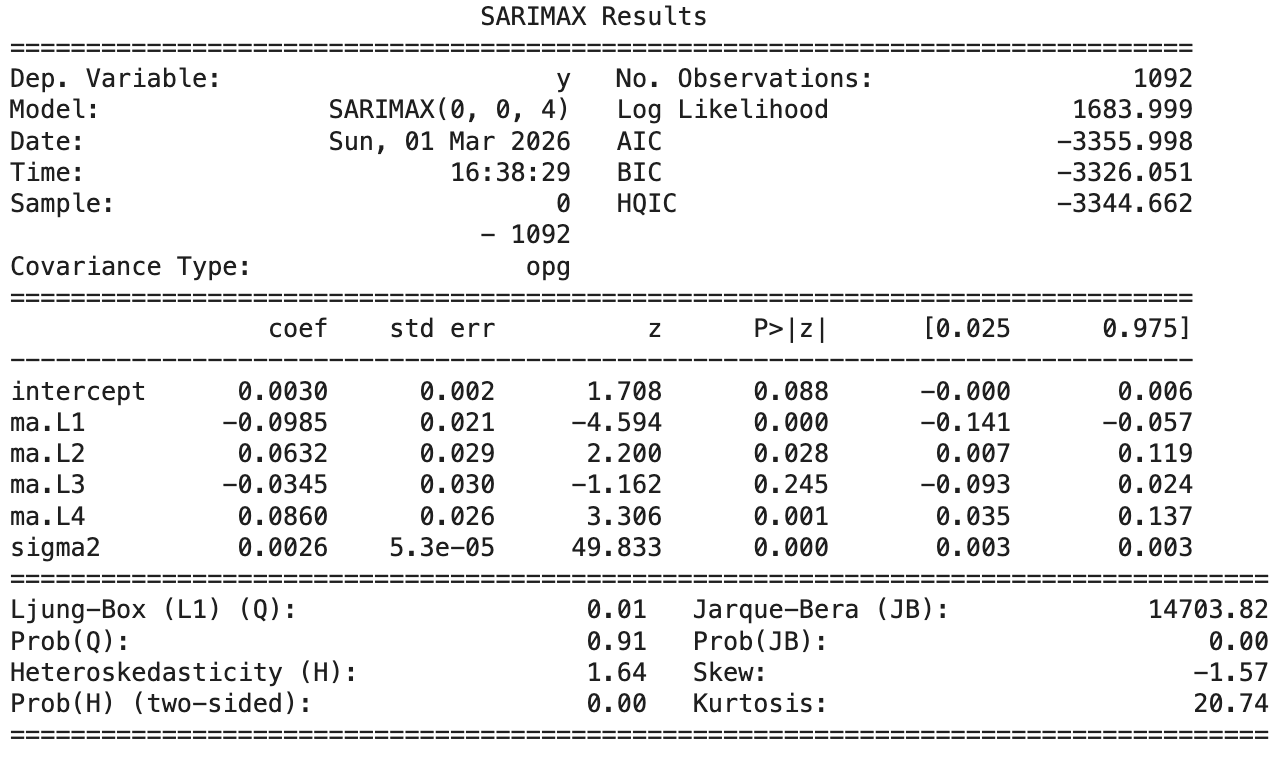

In [77]:
optim_result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -1701.9459245454364
        x: [ 2.944e-03 -9.899e-02  6.285e-02 -3.391e-02  8.538e-02
             2.688e-03]
      nit: 8
      jac: [-6.023e-02 -5.568e-02 -2.613e-02 -1.633e-02 -3.333e-02
             0.000e+00]
     nfev: 91
     njev: 13
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>

# 6) Autoregressive Moving Average Model

We estimate an ARMA(1,10) model as:

$$
Y_{t}
= \phi_{0}
+ \phi_{1} Y_{t-1}
+ \theta_{1}\,\varepsilon_{t-1}
+ \theta_{10}\,\varepsilon_{t-10}
+ \varepsilon_{t}
$$


where:

- $Y_t$ is the observed time series.
- $\phi_{0}$ is the mean of the series.
- $\varepsilon_t$ is white noise with zero mean and constant variance.
- $\phi_{0}, \phi_{1}, \theta_{1}, \theta_{10}$ are the parameters of the model.

In [78]:
model = sm.tsa.statespace.SARIMAX(
    returns,
    order=(1, 0, 10),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)
constrained_results = model.fit_constrained({'ma.L2': 0, 'ma.L3': 0, 'ma.L4': 0, 'ma.L5': 0, 'ma.L6': 0, 'ma.L7': 0,
                                             'ma.L8': 0, 'ma.L9': 0,})

In [79]:
print(constrained_results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1092
Model:              SARIMAX(1, 0, 10)   Log Likelihood                1679.172
Date:                Wed, 01 Jul 2026   AIC                          -3348.344
Time:                        20:11:30   BIC                          -3323.416
Sample:                             0   HQIC                         -3338.905
                               - 1092                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0046      0.003      1.721      0.085      -0.001       0.010
ar.L1            -0.6144      0.104     -5.926      0.000      -0.818      -0.411
ma.L1             0.5016      0.111     

In [80]:
residuals = constrained_results.resid
residuals_acf_pacf = SACF_SPACF(residuals) #model_df=3
residuals_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,0.019366,0.019379,0.410685,0.521622
2,-0.002627,-0.003004,0.418248,0.811295
3,0.001674,0.001789,0.421320,0.935804
4,0.059350,0.059406,4.288981,0.368307
5,-0.017330,-0.019739,4.619042,0.464116
6,0.002008,0.003088,4.623479,0.592928
7,-0.024095,-0.024530,5.262740,0.627934
8,-0.007907,-0.010580,5.331639,0.721613
9,-0.023109,-0.020757,5.920726,0.747825


In [81]:
SACF_SPACF_plotly(residuals, lag_max=24, ylim = [-0.15, 0.15])

We estimate an ARMA(1,10) model as:

$$
Y_{t}
= \phi_{0}
+ \phi_{1} Y_{t-1}
+ \theta_{1}\,\varepsilon_{t-1}
+ \theta_{4}\,\varepsilon_{t-4}
+ \theta_{10}\,\varepsilon_{t-10}
+ \varepsilon_{t}
$$


where:

- $Y_t$ is the observed time series.
- $\phi_{0}$ is the mean of the series.
- $\varepsilon_t$ is white noise with zero mean and constant variance.
- $\phi_{0}, \phi_{1}, \theta_{1}, \theta_{4}, \theta_{10}$ are the parameters of the model.

In [82]:
model = sm.tsa.statespace.SARIMAX(
    returns,
    order=(1, 0, 10),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)
constrained_results = model.fit_constrained({'ma.L2': 0, 'ma.L3': 0, 'ma.L5': 0, 'ma.L6': 0, 'ma.L7': 0,
                                             'ma.L8': 0, 'ma.L9': 0,})

In [83]:
print(constrained_results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1092
Model:              SARIMAX(1, 0, 10)   Log Likelihood                1682.219
Date:                Wed, 01 Jul 2026   AIC                          -3352.438
Time:                        20:11:35   BIC                          -3322.524
Sample:                             0   HQIC                         -3341.112
                               - 1092                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0043      0.003      1.623      0.105      -0.001       0.009
ar.L1            -0.4864      0.133     -3.650      0.000      -0.748      -0.225
ma.L1             0.3822      0.138     

In [84]:
residuals = constrained_results.resid
residuals_acf_pacf = SACF_SPACF(residuals) #model_df=4
residuals_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,0.012686,0.012696,0.176231,0.674633
2,0.013888,0.013740,0.387624,0.823813
3,-0.011637,-0.011999,0.536185,0.910873
4,0.000121,0.000241,0.536201,0.969882
5,0.002984,0.003328,0.545985,0.990343
6,-0.003869,-0.004115,0.562448,0.996994
7,-0.026320,-0.026354,1.325209,0.987753
8,-0.003505,-0.002655,1.338751,0.995073
9,-0.028616,-0.028055,2.242064,0.987036


In [85]:
SACF_SPACF_plotly (residuals, lag_max=24, ylim = [-0.15, 0.15])